# Attack Profile Frame Review
Visual check for `convoy_sim.attack_profiles.DEFAULT_ATTACK_PROFILE_LIBRARY`.

This notebook renders **three frames** per profile (first, middle, last) and writes:
`results/frames/attack_profile_previews/<PROFILE_ID>/frame_0001.png`\n`results/frames/attack_profile_previews/<PROFILE_ID>/frame_<middle>.png`\n`results/frames/attack_profile_previews/<PROFILE_ID>/frame_<last>.png`.


In [2]:
#Imports
import os, sys
import csv
import json
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../.."))) #Allow for imports from src
import convoy_sim.viz_attack as viz_attack
importlib.reload(viz_attack)

from convoy_sim.attack_profiles import AttackProfileLibrary, DEFAULT_ATTACK_PROFILE_LIBRARY
from convoy_sim.dynamics import ConvoyFormation, ConvoyKinematics, RouteLeg, RoutePlan, ZigZagPlan
from convoy_sim.simulation import HitSlowdownSpec, init_dynamic_hit_state
from convoy_sim.viz import plot_convoy_planview
from scenarios.convoy_profiles import get_convoy_layout_profile

from convoy_sim.profile_audit import audit_attack_profiles


In [3]:
# --- Config ---
PROFILE_LIBRARY: AttackProfileLibrary = DEFAULT_ATTACK_PROFILE_LIBRARY
SELECT_PROFILE_IDS: list[str] | None = None
CONVOY_PROFILE = 'convoy_layout_1'  # Default Layout
RNG_SEED = 1945

RUN_MODE = 'verify'  # 'fast' or 'verify'
FPS = 5

if RUN_MODE == 'fast':
    SIM_DURATION_S = 300.0
    HIT_DT = 0.5
    PROFILE_LIMIT = 6
else:
    SIM_DURATION_S = 600.0
    HIT_DT = 1.0 / float(FPS)
    PROFILE_LIMIT = None

LAST_FRAME_INDEX = int(SIM_DURATION_S * FPS)
MIDDLE_FRAME_INDEX = LAST_FRAME_INDEX // 2
FRAME_INDICES = [1, MIDDLE_FRAME_INDEX, LAST_FRAME_INDEX]  # first, middle, last
FRAME_TIMES_S = {idx: idx / FPS for idx in FRAME_INDICES}

OUTPUT_ROOT = Path('results/frames/attack_profile_previews')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

AUDIT_CSV_PATH = Path('results/diag/attack_profile_geometry_audit.csv')
AUDIT_JSON_PATH = Path('results/diag/attack_profile_geometry_audit.json')
EXCLUDE_IMPLAUSIBLE_FROM_RENDER = False

# Requested fixed bounds for layout preview
LAYOUT_XLIM = (-3000.0, 3000.0)
LAYOUT_YLIM = (-5000, 5000.0)

# XLIM & YLIM for Frames
FRAME_VIEW_BOUNDS = (-3500, 7000, -4500, 4500)

APPLY_HIT_SLOWDOWN = False
HIT_SLOWDOWN = HitSlowdownSpec(enabled=APPLY_HIT_SLOWDOWN, decay_rate=0.02, min_factor=0.4)

print('RUN_MODE:', RUN_MODE)
print('FPS:', FPS)
print('Simulation duration (s):', SIM_DURATION_S)
print('Hit tracking dt (s):', HIT_DT)
print('Frame indices:', FRAME_INDICES)
print('Frame times (s):', FRAME_TIMES_S)
print('Output root:', OUTPUT_ROOT)
print('Audit CSV:', AUDIT_CSV_PATH)


FPS: 5
Simulation duration (s): 600.0
Frame indices: [1, 1500, 3000]
Frame times (s): {1: 0.2, 1500: 300.0, 3000: 600.0}
Output root: results/frames/attack_profile_previews


## Convoy Layout Preview (No Attack)

Layout-only view using existing `plot_convoy_planview` with your requested fixed axis limits.


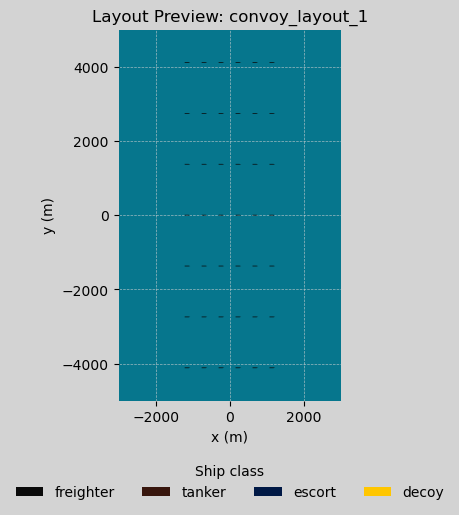

In [4]:
ships_layout_only = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()
fig, ax = plt.subplots(figsize=(10, 7), facecolor='lightgrey')
plot_convoy_planview(
    ships_layout_only,
    ax=ax,
    title=f'Layout Preview: {CONVOY_PROFILE}',
    color_by='class',
    show_footprint=False,
    ship_marker='ship',
    rotate_by_heading=True,
    use_hull_dimensions=True,
    axes_facecolor='#06768d',)

ax.set_xlim(*LAYOUT_XLIM)
ax.set_ylim(*LAYOUT_YLIM)

#Drop legend down more so it does not overlap x-axis.
leg = ax.get_legend()
if leg is not None:
    leg.set_bbox_to_anchor((0.5, -0.3))

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_aspect('equal', adjustable='box')
fig.subplots_adjust(bottom=0.35)
plt.show()


In [5]:
def _build_demo_dynamics(ships_t0, t_end_s: float):
    formation = ConvoyFormation(
        ships0=ships_t0,
        convoy_origin0=np.array([0.0, 0.0], dtype=float),
        convoy_heading0=0.0,)
    route = RoutePlan(legs=[RouteLeg(duration_s=max(120.0, float(t_end_s)), heading_rad=0.0)])
    zigzag = ZigZagPlan(enabled=True, amplitude_rad=0.12, period_s=60.0, phase_s=0.0, waveform='sine')
    kin = ConvoyKinematics(route=route, zigzag=zigzag)
    return formation, kin


## Profile Geometry Audit (Fast pre-check)

Runs a geometry plausibility audit before rendering. This is fast and helps you fix implausible misses before expensive visual runs.


In [ ]:
ships_for_audit = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()
profiles = PROFILE_LIBRARY.profiles
if SELECT_PROFILE_IDS is not None:
    selected = set(SELECT_PROFILE_IDS)
    profiles = [p for p in profiles if p.profile_id in selected]
if PROFILE_LIMIT is not None:
    profiles = profiles[: int(PROFILE_LIMIT)]

audit_rows = audit_attack_profiles(profiles, ships_for_audit)
audit_by_id = {row['profile_id']: row for row in audit_rows}

AUDIT_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
with AUDIT_CSV_PATH.open('w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            'profile_id', 'name', 'mode', 'u_pos_x', 'u_pos_y',
            'range_to_centroid_m', 'intent_bearing_rad', 'active_bearing_rad',
            'bearing_error_deg', 'spread_deg', 'flag_count', 'flags',
            'severity', 'suggested_label',
        ],
    )
    writer.writeheader()
    for row in audit_rows:
        out = dict(row)
        out['flags'] = ';'.join(row.get('flags', []))
        writer.writerow(out)

AUDIT_JSON_PATH.parent.mkdir(parents=True, exist_ok=True)
AUDIT_JSON_PATH.write_text(json.dumps(audit_rows, indent=2), encoding='utf-8')

n_implausible = sum(1 for row in audit_rows if row['suggested_label'] == 'implausible_geometry')
n_near_miss = sum(1 for row in audit_rows if row['suggested_label'] == 'credible_near_miss')
n_hit_threat = sum(1 for row in audit_rows if row['suggested_label'] == 'credible_hit_threat')

print('Audit summary:', {
    'profiles': len(audit_rows),
    'credible_hit_threat': n_hit_threat,
    'credible_near_miss': n_near_miss,
    'implausible_geometry': n_implausible,
})
print('Top 5 severity rows:')
for row in audit_rows[:5]:
    print(
        row['profile_id'],
        f"severity={row['severity']:.1f}",
        f"error={row['bearing_error_deg']:.1f}deg",
        f"flags={row['flags']}",
    )

if EXCLUDE_IMPLAUSIBLE_FROM_RENDER:
    bad = {row['profile_id'] for row in audit_rows if row['suggested_label'] == 'implausible_geometry'}
    profiles = [p for p in profiles if p.profile_id not in bad]
    print(f'Excluded {len(bad)} implausible profiles from render pass.')

print('Audit CSV written to:', AUDIT_CSV_PATH)
print('Audit JSON written to:', AUDIT_JSON_PATH)


In [ ]:
ships_t0 = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()
dynamics = _build_demo_dynamics(ships_t0, SIM_DURATION_S)
hit_dt = float(HIT_DT)

#Uses `profiles` and `audit_by_id` from the audit cell.
saved = []
for idx, profile in enumerate(profiles):
    rng = np.random.default_rng(RNG_SEED + idx)
    torpedoes = profile.build_torpedoes(rng=rng)
    hit_state = init_dynamic_hit_state(0.0)

    u_pos = np.asarray(profile.u_pos, dtype=float)

    out_dir = OUTPUT_ROOT / profile.profile_id
    out_dir.mkdir(parents=True, exist_ok=True)

    written_frames: list[str] = []
    for frame_idx in sorted(FRAME_INDICES):
        frame_name = f'frame_{frame_idx:04d}.png'
        frame_time_s = float(FRAME_TIMES_S[frame_idx])
        out_path = out_dir / frame_name

        fig, ax = plt.subplots(figsize=(6, 6), facecolor='lightgrey')
        viz_attack.render_attack_frame(
            ships_t0=ships_t0,
            torpedoes=torpedoes,
            t_global=frame_time_s,
            t_max=SIM_DURATION_S,
            dynamics=dynamics,
            ax=ax,
            color_by='class',
            show_trails=True,
            trail_length_s=40.0,
            show_footprint=False,
            ship_marker='ship',
            rotate_by_heading=True,
            use_hull_dimensions=True,
            trail_color='red',
            legend_bbox_to_anchor=(0.5, -0.50),
            view_bounds=FRAME_VIEW_BOUNDS,
            hide_spines=True,
            hit_state=hit_state,
            hit_dt=hit_dt,
            apply_hit_slowdown=APPLY_HIT_SLOWDOWN,
            hit_slowdown=HIT_SLOWDOWN,
            figure_facecolor='lightgrey',
            show_u_boat=True,
            u_boat_position=u_pos,
            u_boat_marker='o',
            u_boat_color='black',
            u_boat_size=24.0,
            u_boat_label='U-boat',
        )
        fig.subplots_adjust(bottom=0.32)
        fig.savefig(out_path, dpi=150)
        plt.close(fig)

        written_frames.append(frame_name)
        saved.append((profile.profile_id, frame_idx, str(out_path)))

    row = audit_by_id.get(profile.profile_id)
    label = row['suggested_label'] if row is not None else 'n/a'
    err = row['bearing_error_deg'] if row is not None else float('nan')
    print(f"Completed {profile.profile_id} [{label}, err={err:.1f}deg]: {', '.join(written_frames)}")

print(f'Rendered {len(saved)} total frame images across {len(profiles)} profiles.')


Completed P01: frame_0001.png, frame_1500.png, frame_3000.png
Completed P02: frame_0001.png, frame_1500.png, frame_3000.png
Completed P03: frame_0001.png, frame_1500.png, frame_3000.png
Completed P04: frame_0001.png, frame_1500.png, frame_3000.png
Completed P05: frame_0001.png, frame_1500.png, frame_3000.png
Completed P06: frame_0001.png, frame_1500.png, frame_3000.png
Completed P07: frame_0001.png, frame_1500.png, frame_3000.png
Completed P08: frame_0001.png, frame_1500.png, frame_3000.png
Completed P09: frame_0001.png, frame_1500.png, frame_3000.png
Completed P10: frame_0001.png, frame_1500.png, frame_3000.png
Completed P11: frame_0001.png, frame_1500.png, frame_3000.png
Completed P12: frame_0001.png, frame_1500.png, frame_3000.png
Completed P13: frame_0001.png, frame_1500.png, frame_3000.png
Completed P14: frame_0001.png, frame_1500.png, frame_3000.png
Completed P15: frame_0001.png, frame_1500.png, frame_3000.png
Completed P16: frame_0001.png, frame_1500.png, frame_3000.png
Complete

In [11]:
#Run U-Boat Miss Flag
repo = "/Users/matthewplambeck/Desktop/Convoy Layout Project"
!PYTHONPATH="{repo}" python -m experiments.audit_attack_profiles --convoy-profile convoy_layout_1


Wrote CSV: results/diag/attack_profile_geometry_audit.csv
Wrote JSON: results/diag/attack_profile_geometry_audit.json
Summary: {'profiles': 25, 'credible_hit_threat': 15, 'credible_near_miss': 0, 'implausible_geometry': 10}
Top 5 highest-severity profiles:
  P14: severity=100.0, error=75.4deg, flags=['near_range_large_error', 'fan_not_covering_target']
  P15: severity=100.0, error=99.2deg, flags=['near_range_large_error', 'fan_not_covering_target', 'near_range_opposite_direction']
  P16: severity=100.0, error=119.7deg, flags=['near_range_large_error', 'fan_not_covering_target', 'near_range_opposite_direction']
  P17: severity=100.0, error=81.9deg, flags=['near_range_large_error', 'fan_not_covering_target']
  P18: severity=100.0, error=180.0deg, flags=['near_range_large_error', 'fan_not_covering_target', 'near_range_opposite_direction']
